# Fitting the four-mode Gridium spectrum (frozen 2026-08-18 baseline)

We measured the qubit's spectrum twice, at two different settings of the outer
flux loop. Each measurement is a 2D map: we sweep the KITE bias current along
the bottom, sweep the drive frequency up the side, and record how much signal
comes back. Wherever the drive hits a real transition of the circuit, a bright
line shows up.

This notebook goes through the whole thing in order:

1. load and look at the two measured maps
2. pull the bright lines ("ridges") out of them
3. fit the circuit model to those lines
4. put the fitted points back on the measured maps to see how it did
5. draw the full simulated spectrum on top of the measurement
6. draw the simulated spectrum on its own

step 3 is the expensive one and is switched off by
default, so the notebook just loads the fit that was already done.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from IPython.display import display

# Find the repository root so the imports below work wherever this is opened.
ROOT = Path.cwd().resolve()
while not (ROOT / "Circuit_Objs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "Circuit_Objs").exists():
    raise RuntimeError("Run this notebook from inside the 2q_gridium repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Where fit results are read from and written to.  This has to be set before the
# fitting code is imported, so if you change it, restart the kernel.
RESULTS_DIRECTORY = ROOT / "fitting" / "four_mode_gkp_fitting_baseline_20260818" / "results"
os.environ["GRIDIUM_TWO_CUT_RESULTS_DIRECTORY"] = str(RESULTS_DIRECTORY)

# Run the eigensolves in separate processes rather than threads, and keep the
# big-basis check to a few workers so it does not exhaust memory.
os.environ.setdefault("GRIDIUM_FIT_EXECUTOR_BACKEND", "process")
os.environ.setdefault("GRIDIUM_MAX_REFINED_WORKERS", "4")
# Each worker is its own process, and Apple's Accelerate library would otherwise
# start several threads inside each one -- many more threads than cores.  This
# holds it to one thread per worker.  (threadpoolctl cannot do this on macOS.)
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

from fitting.four_mode_gkp_fitting_baseline_20260818.src import (
    FIT_PROFILES,
    TWO_CUT_OVERLAY_PATH,
    TWO_CUT_SUMMARY_PATH,
    extract_lower_v_branches,
    prepare_two_cut_experiments,
    run_two_cut_full_workflow,
)

if TWO_CUT_SUMMARY_PATH.parent != RESULTS_DIRECTORY:
    raise RuntimeError(
        "The fitting code was already imported with a different results folder. "
        "Restart the kernel and run from the top."
    )

print("repository :", ROOT)
print("results in :", RESULTS_DIRECTORY)

repository : /Users/eric_jin/2q_gridium-main
results in : /Users/eric_jin/2q_gridium-main/fitting/four_mode_gkp_fitting_baseline_20260818/results


## 1. The two measured maps

`prepare_two_cut_experiments()` reads the two raw files and tidies them up a
bit: it drops a dead row at the edge, patches over isolated missing samples, and
works out where the pattern's mirror line sits so the two halves match.

the spectrum repeats as you change the KITE flux, and
the middle of the pattern is the special "protected" point. The dotted vertical
line marks it, and the axis along the top converts bias current into flux phase,
where the protected point sits at $\pi$



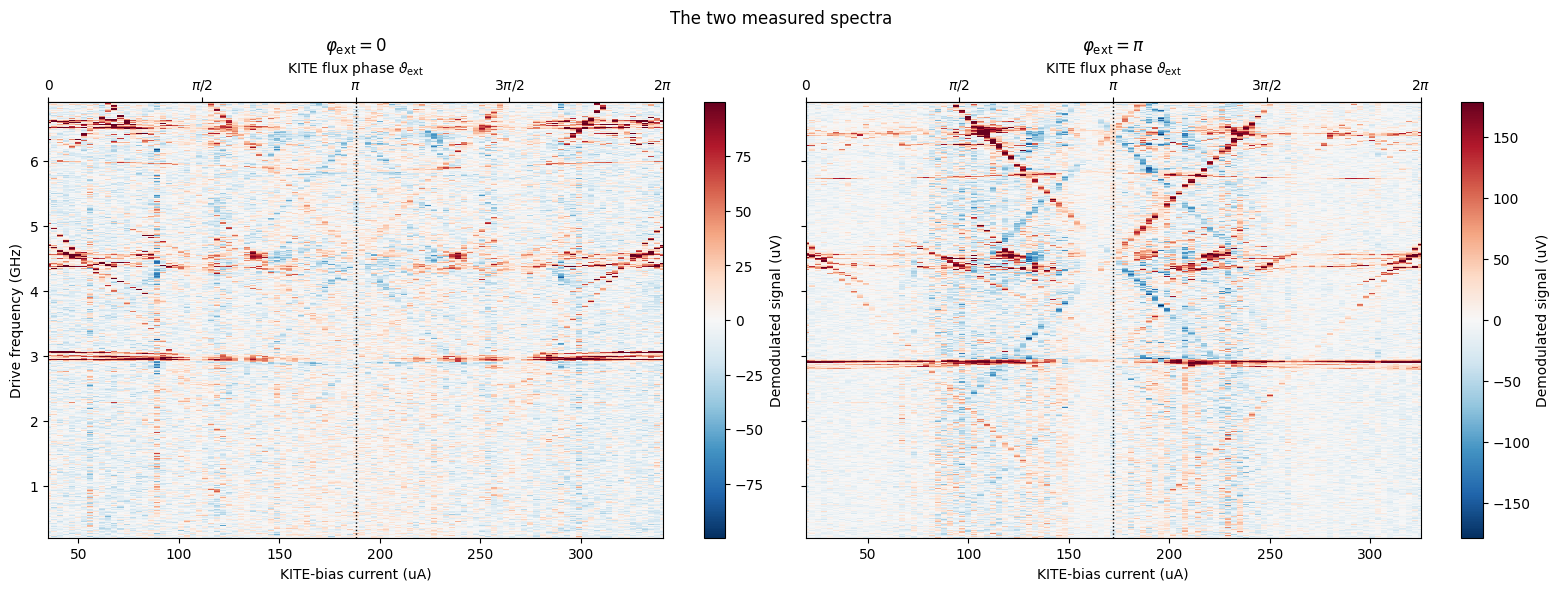

phi0: 103 currents x 1381 frequencies, mirror line at 188 uA
phipi: 103 currents x 1381 frequencies, mirror line at 172 uA


In [2]:
cuts = prepare_two_cut_experiments()
cut_by_name = {cut.name: cut for cut in cuts}

FREQUENCY_LIMITS = (0.2, 6.9)
TITLES = {"phi0": r"$\varphi_{\rm ext}=0$", "phipi": r"$\varphi_{\rm ext}=\pi$"}


def add_theta_axis(axis, cut):
    """Add the flux-phase axis along the top, with the protected point at pi."""
    center, half_period = cut.symmetry_center_uA, cut.half_period_uA
    forward = lambda current: np.pi + np.pi * (current - center) / half_period
    inverse = lambda theta: center + half_period * (theta - np.pi) / np.pi
    top = axis.secondary_xaxis("top", functions=(forward, inverse))
    top.set_xticks(
        [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
        ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"],
    )
    top.set_xlabel(r"KITE flux phase $\vartheta_{\rm ext}$")


def draw_measured_map(axis, cut, alpha=1.0):
    """The measured spectrum as a background image, plus the usual decorations."""
    limit = np.nanpercentile(np.abs(cut.spectrum.signal_uV), 99.5)
    mesh = axis.pcolormesh(
        cut.spectrum.current_uA, cut.spectrum.frequency_GHz,
        cut.spectrum.signal_uV.T, shading="auto", cmap="RdBu_r",
        vmin=-limit, vmax=limit, rasterized=True, alpha=alpha, zorder=1,
    )
    axis.axvline(cut.symmetry_center_uA, color="black", ls=":", lw=1, zorder=4)
    axis.set(xlabel="KITE-bias current (uA)", title=TITLES[cut.name],
             xlim=(float(cut.spectrum.current_uA.min()),
                   float(cut.spectrum.current_uA.max())),
             ylim=FREQUENCY_LIMITS)
    add_theta_axis(axis, cut)
    return mesh


fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
for axis, cut in zip(axes, cuts):
    mesh = draw_measured_map(axis, cut)
    fig.colorbar(mesh, ax=axis, label="Demodulated signal (uV)")
axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("The two measured spectra")
plt.show()

for cut in cuts:
    print(f"{cut.name}: {cut.spectrum.current_uA.size} currents x "
          f"{cut.spectrum.frequency_GHz.size} frequencies, "
          f"mirror line at {cut.symmetry_center_uA:.0f} uA")

## 2. Pulling the bright ridges out

Before anything can be fitted, the bright ridges have to be turned into numbers.


First, for each bias current we take a vertical slice, subtract the slowly
varying background, and pick out the peaks that stand clearly above the noise.
That gives a cloud of individual detections.

Second, those detections get joined up into tracks: a peak at one current is
linked to the nearest peak at the next current, as long as the jump is small
enough to be believable. Each track is one continuous branch

The lower "V" at $\varphi_{\rm ext}=\pi$ is handled separately (purple below),
because it dips below the bottom of the measured window and comes back up, so
the ordinary left-to-right linking loses it.

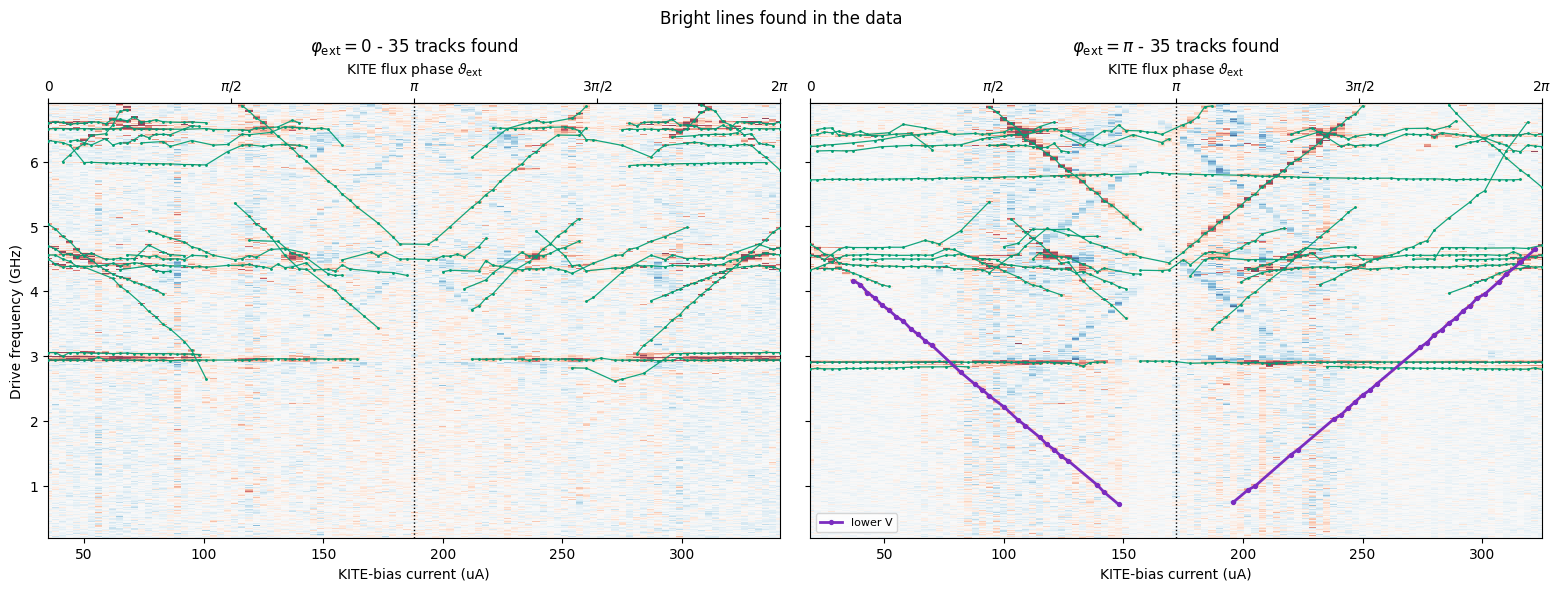

phi0: 35 tracks, 667 points total
phipi: 35 tracks, 776 points total


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
for axis, cut in zip(axes, cuts):
    draw_measured_map(axis, cut, alpha=0.72)

    for track in cut.tracks:
        axis.plot(track.currents_uA, track.frequencies_GHz, color="#009e73",
                  lw=0.9, marker=".", ms=2.2, alpha=0.92, zorder=3)

    if cut.name == "phipi":                      # the lower V, found separately
        arms, _info = extract_lower_v_branches(cut)
        for index, arm in enumerate(arms):
            axis.plot(arm.currents_uA, arm.frequencies_GHz, color="#7b2cbf",
                      lw=2.0, marker="o", ms=2.8, zorder=3,
                      label="lower V" if index == 0 else None)
        axis.legend(loc="lower left", fontsize=8)

    axis.set_title(f"{TITLES[cut.name]} - {len(cut.tracks)} tracks found")

axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("Bright lines found in the data")
plt.show()

for cut in cuts:
    points = sum(len(t.frequencies_GHz) for t in cut.tracks)
    print(f"{cut.name}: {len(cut.tracks)} tracks, {points} points total")

## 3. Running the fit

The model is one circuit Hamiltonian shared by both measurements — same
parameters, only the outer flux differs. The fit tries different parameter
values, works out where the circuit's transitions should appear, matches those
predictions to the tracks from step 2, and nudges the parameters until the
predicted lines sit on the measured ones.

It runs in stages: rough and fast first, then finer, then a last pass at high
accuracy.

There are three settings to pick from:

| profile | what it does | roughly how long |
|---|---|---|
| `preview` | fits on a small basis, checks the answer on a bigger one | ~1.5-2.5 h |
| `production` | like `preview`, plus an extra pass on the worst branch and a convergence check | ~5-7 h |

`RUN_FIT` is off by default, so the cell below just loads the fit that was
already done — that takes a second. Flip it to `True` to actually fit.

A couple of things to know before you do: the kernel has to stay alive for the
whole run, so don't close the notebook or let the machine sleep, and the results
folder gets overwritten when the run finishes. Copy `results/` somewhere safe
first if you want to keep the current numbers for comparison.

In [4]:
RUN_FIT = True      # the frozen result is what this notebook is for

FIT_PROFILE = "production" 

WORKERS = 8

OVERLAY_POINTS = 21


assert FIT_PROFILE in FIT_PROFILES
print("available profiles:")
for name, profile in FIT_PROFILES.items():
    print(f"   {name:<13s} {profile}")
print(f"\nselected: {FIT_PROFILE}    RUN_FIT = {RUN_FIT}\n")

if RUN_FIT:
    try:
        summary = run_two_cut_full_workflow(
            workers=WORKERS, overlay_points=OVERLAY_POINTS, profile=FIT_PROFILE,
        )
        print("Fit finished and passed its quality checks.")
    except RuntimeError as error:
        # The results are still written before this is raised, so keep them and
        # say so rather than losing the run.
        if not (TWO_CUT_SUMMARY_PATH.exists() and TWO_CUT_OVERLAY_PATH.exists()):
            raise
        summary = json.loads(TWO_CUT_SUMMARY_PATH.read_text())
        print("Fit finished but did NOT pass its quality checks:", error)
elif TWO_CUT_SUMMARY_PATH.exists() and TWO_CUT_OVERLAY_PATH.exists():
    summary = json.loads(TWO_CUT_SUMMARY_PATH.read_text())
    print("Loaded the saved fit -- nothing was recomputed.")
    print("To fit for real, set RUN_FIT = True above and run this cell again.")
else:
    raise FileNotFoundError(
        f"No saved fit in {RESULTS_DIRECTORY}. Set RUN_FIT=True and run this cell."
    )

with np.load(TWO_CUT_OVERLAY_PATH, allow_pickle=False) as saved:
    overlay = {name: saved[name] for name in saved.files}

available profiles:
   preview       FitProfile(name='preview', optimizer_basis='preview', validation_basis='intermediate', use_basis_correction=True, run_branch_balance=False)
   production    FitProfile(name='production', optimizer_basis='preview', validation_basis='intermediate', use_basis_correction=True, run_branch_balance=True)

selected: production    RUN_FIT = True


=== coarse_inductive_and_global ===
accepted parameters: {"EC": 0.77, "ECS": 8.13, "EJ": 8.459584016481616, "EJS": 1.13, "EL": 0.5016715483688862, "ELK": 0.4871743264666818, "eC": 0.7, "eP": 1.2232559362364772, "eps_J": 0.0, "eps_LK": 0.05, "ng": 0.0}

=== coarse_nonlinear_and_charging ===
accepted parameters: {"EC": 0.7444139659885542, "ECS": 8.06907396768567, "EJ": 8.459584016481616, "EJS": 1.1344311345767109, "EL": 0.5016715483688862, "ELK": 0.4871743264666818, "eC": 0.7158980989700897, "eP": 1.2232559362364772, "eps_J": 0.0, "eps_LK": 0.05, "ng": 0.0}

=== coarse_kite_asymmetry ===
accepted parameters: {"EC": 0

### Results

The energies are all in GHz. `1-sigma` is how tightly the data pins each one
down — where it is missing, the saved fit predates that calculation.

The error is quoted as RMS: the typical gap in MHz between where the model puts
a line and where it actually is.

In [5]:
names = {
    "EJ": "junction energy of the KITE arms",
    "EC": "charging energy of the KITE arms",
    "EL": "inductance of the big loop",
    "ELK": "inductance inside the KITE",
    "EJS": "phase-slip strength",
    "ECS": "charging energy of the phase-slip element",
    "eC": "capacitance imbalance",
    "eP": "phase-slip asymmetry",
    "eps_J": "junction imbalance in the KITE",
    "eps_LK": "inductance imbalance in the KITE",
}
sigma = (summary.get("parameter_uncertainties") or {}).get("one_sigma_GHz", {})

rows = []
for key, description in names.items():
    if key not in summary["final_parameters_GHz"]:
        continue
    rows.append({
        "parameter": key,
        "value (GHz)": round(summary["final_parameters_GHz"][key], 4),
        "1-sigma": round(sigma[key], 4) if key in sigma else None,
        "what it is": description,
    })
display(pd.DataFrame(rows).set_index("parameter"))

metrics = summary["final_metrics"]
print("typical error between model and data:")
for name in ("phi0", "phipi", "combined"):
    if name in metrics:
        m = metrics[name]
        print(f"   {name:<9s} {m['rms_MHz']:6.1f} MHz over {m['points']:4d} points"
              f"   ({100*m['fraction_within_100_MHz']:.0f}% within 100 MHz)")

gate = summary.get("quality_gate", {})
print(f"\npassed its quality checks: {gate.get('passed')}")
for check, ok in (gate.get("checks") or {}).items():
    if not ok:
        print(f"   failed: {check}")

,value (GHz),1-sigma,what it is
parameter,,,
EJ,8.3913,None,junction energy of the KITE arms
EC,0.7913,None,charging energy of the KITE arms
EL,0.5137,None,inductance of the big loop
ELK,0.5029,None,inductance inside the KITE
EJS,1.1760,None,phase-slip strength
ECS,8.0563,None,charging energy of the phase-slip element
eC,0.7181,None,capacitance imbalance
eP,1.3472,None,phase-slip asymmetry
eps_J,0.0017,None,junction imbalance in the KITE


typical error between model and data:
   phi0        75.2 MHz over  387 points   (80% within 100 MHz)
   phipi       70.3 MHz over  503 points   (89% within 100 MHz)
   combined    72.5 MHz over  890 points   (85% within 100 MHz)

passed its quality checks: True


## 4. Where the fit actually landed

Every point below is a measured point the fit used, dropped back onto the map it
came from. The colour is how far off the model was there: white is spot on,
dark red is 300 MHz out.

This is the honest view of the fit. Bright lines with no dots on them are
branches the fit never used — either the detector missed them, or the model had
nothing to match them to.

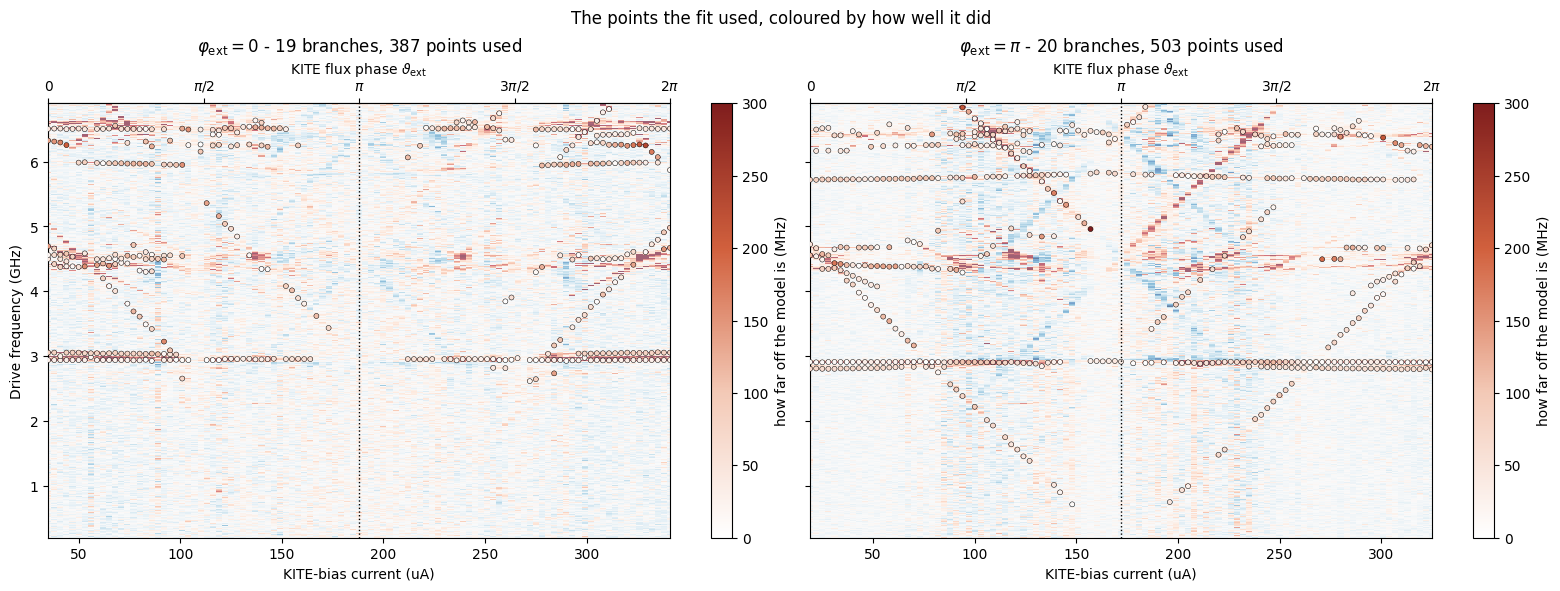

In [6]:
MISS_LIMIT_MHz = 300.0
miss_cmap = LinearSegmentedColormap.from_list(
    "miss", ["#ffffff", "#f3c9b6", "#d1603d", "#7f1d1d"]
)
miss_norm = Normalize(vmin=0.0, vmax=MISS_LIMIT_MHz)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
for axis, cut in zip(axes, cuts):
    draw_measured_map(axis, cut, alpha=0.62)

    rows = [r for r in summary["final_assignments"] if r["cut_name"] == cut.name]
    current = np.concatenate([r["current_uA"] for r in rows])
    observed = np.concatenate([r["observed_GHz"] for r in rows])
    miss = np.abs(np.concatenate([r["residual_MHz"] for r in rows]))
    axis.scatter(current, observed, c=miss, cmap=miss_cmap, norm=miss_norm,
                 s=13, linewidths=0.35, edgecolors="black", zorder=3)
    axis.set_title(f"{TITLES[cut.name]} - {len(rows)} branches, "
                   f"{len(current)} points used")

    fig.colorbar(ScalarMappable(norm=miss_norm, cmap=miss_cmap), ax=axis,
                 label="how far off the model is (MHz)")

axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("The points the fit used, coloured by how well it did")
plt.show()

## 5. The simulated spectrum on top of the measurement

Now the whole model, not just the points that were fitted. Each line is a
transition the circuit can make.

solid lines start from the ground state. Dashed ones start from the first
excited state — those only show up because the qubit is a bit warm, and they
were not fitted.

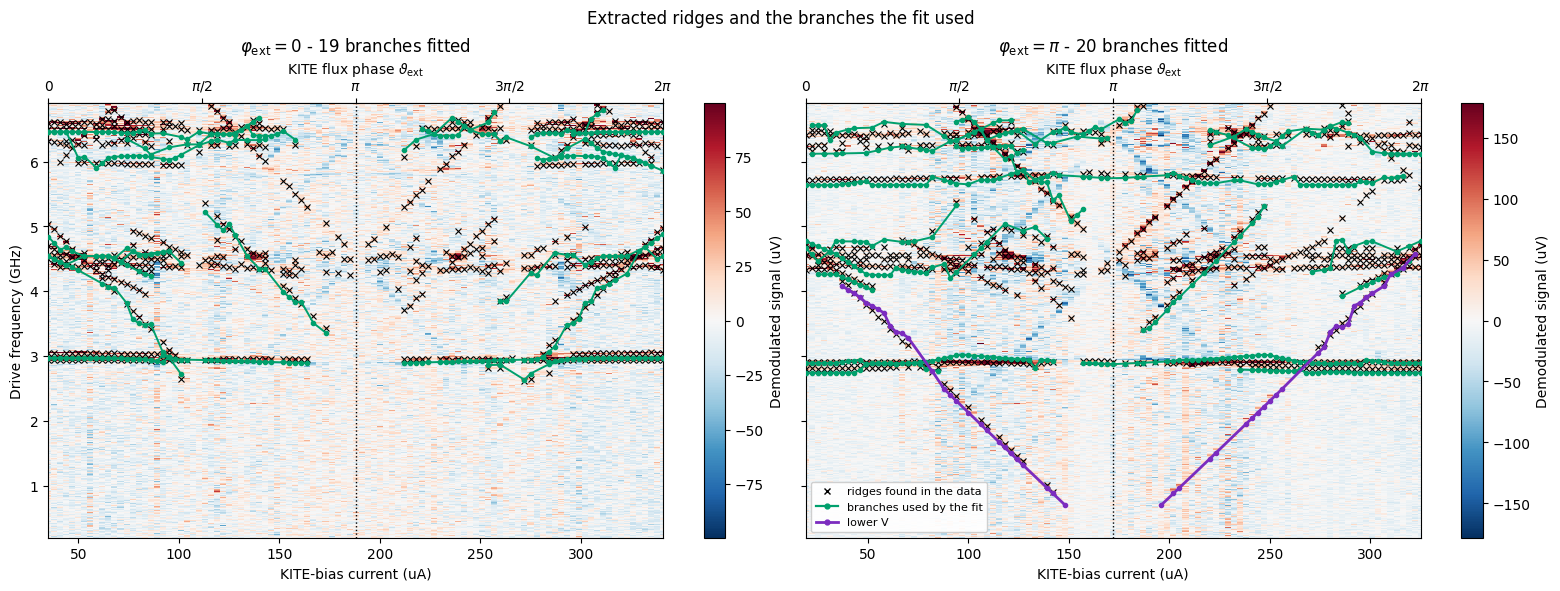

phi0: 24 transitions drawn
phipi: 24 transitions drawn


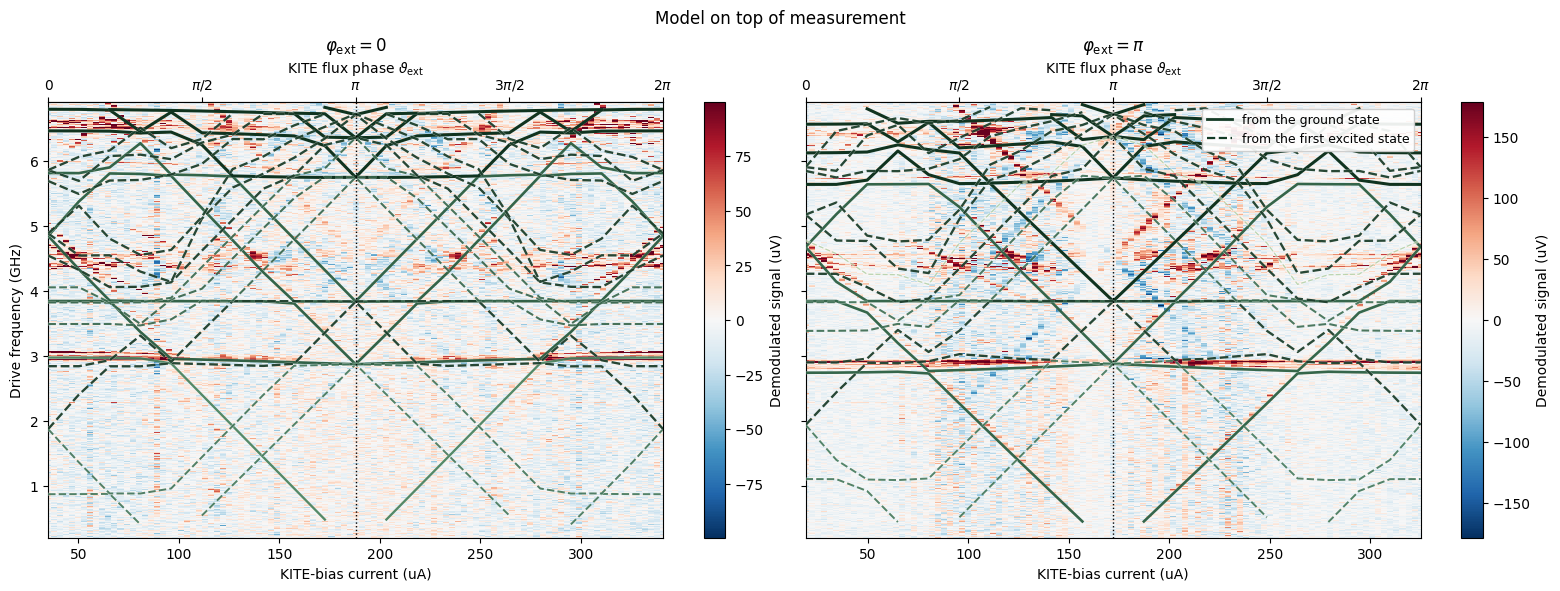

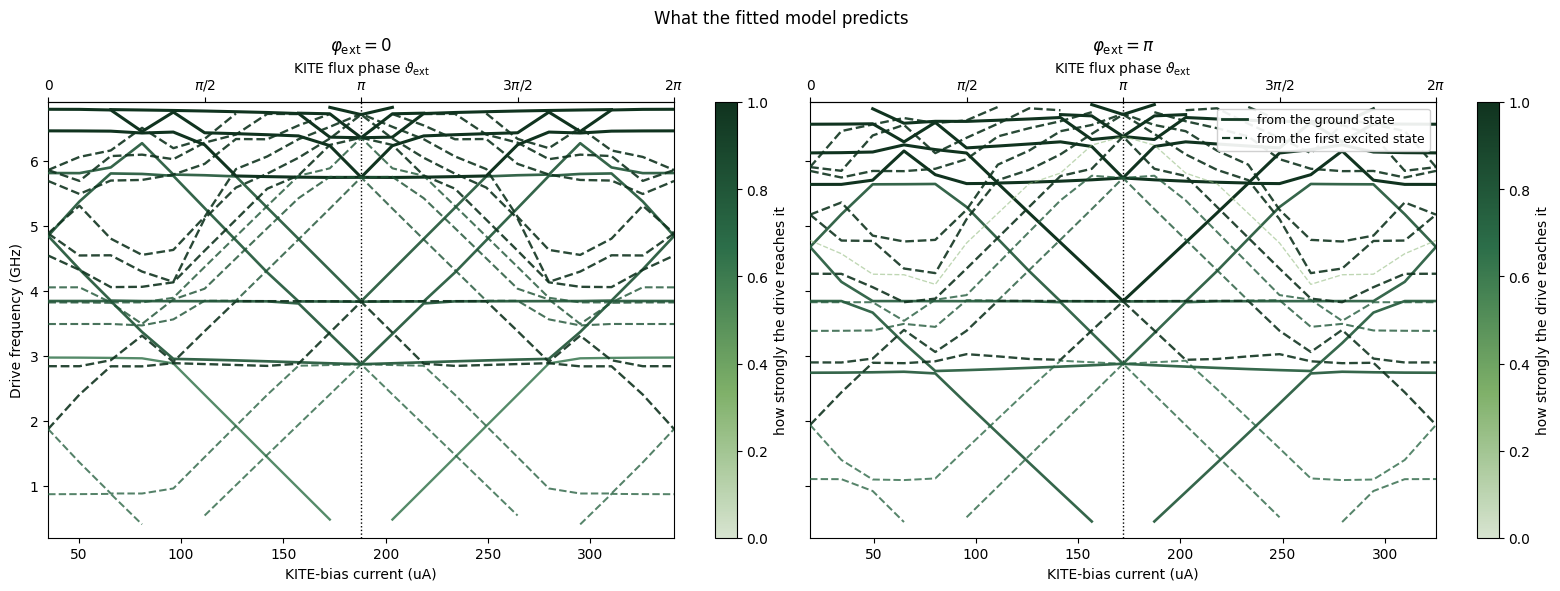

In [13]:
BRIGHTNESS_FLOOR = 0.02        # skip transitions the drive basically cannot reach
SHOW_WARM = True               # False hides the dashed (warm) family

# Light -> dark, so the transitions that matter are the darkest marks on the page.
DRIVE_CMAP = LinearSegmentedColormap.from_list(
    "drive_strength", ["#d7e4d0", "#7fb069", "#2c6e49", "#10331f"]
)
drive_norm = Normalize(vmin=0.0, vmax=1.0)


def draw_simulated_lines(axis, cut, show_warm=True, halo=False):
    """Draw every transition the model predicts for this cut."""
    import matplotlib.patheffects as path_effects
    effects = ([path_effects.withStroke(linewidth=2.2, foreground="white",
                                        alpha=0.55)] if halo else None)
    current = overlay[f"{cut.name}_simulation_current_uA"]
    frequencies = overlay[f"{cut.name}_transition_frequencies_GHz"]
    weights = overlay[f"{cut.name}_relative_matrix_element"]
    initial = overlay[f"{cut.name}_initial_states"]

    drawn = 0
    for index in range(frequencies.shape[1]):
        column = weights[:, index]
        strength = float(np.nanmax(column)) if np.isfinite(column).any() else 0.0
        if strength < BRIGHTNESS_FLOOR:
            continue
        from_ground = int(initial[index]) == 0
        if not from_ground and not show_warm:
            continue
        line = frequencies[:, index]
        inside = (np.isfinite(line) & (line >= FREQUENCY_LIMITS[0])
                  & (line <= FREQUENCY_LIMITS[1]))
        if not inside.any():
            continue
        axis.plot(
            current, np.where(inside, line, np.nan),
            color=DRIVE_CMAP(drive_norm(strength)),
            linestyle="-" if from_ground else "--",
            linewidth=(0.8 + 1.4 * strength) if from_ground else (0.7 + 1.0 * strength),
            alpha=(0.55 + 0.45 * strength) if from_ground else (0.45 + 0.45 * strength),
            path_effects=effects, zorder=3,
        )
        drawn += 1
    return drawn


def add_transition_legend(axis, show_warm=True):
    handles = [Line2D([0], [0], color=DRIVE_CMAP(0.95), lw=2.0,
                      label="from the ground state")]
    if show_warm:
        handles.append(Line2D([0], [0], color=DRIVE_CMAP(0.95), lw=1.6, ls="--",
                              label="from the first excited state"))
    axis.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.92)

# ---------------------------------------------------------------------------
# What the extractor found and what the fit actually used.
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
for axis, cut in zip(axes, cuts):
    mesh = draw_measured_map(axis, cut, alpha=1.0)

    # black crosses: every ridge the extractor picked out of the data
    for track in cut.tracks:
        axis.plot(track.currents_uA, track.frequencies_GHz, ls="none",
                  marker="x", ms=4, mew=0.8, color="black", zorder=4)

    # coloured lines: the branches the fit used, drawn where the model puts them
    rows = [r for r in summary["final_assignments"] if r["cut_name"] == cut.name]
    for row in rows:
        is_lower_v = str(row.get("track_role", "")).startswith("lower_v")
        axis.plot(row["current_uA"], row["predicted_GHz"],
                  color="#7b2cbf" if is_lower_v else "#00a06d",
                  lw=2.0 if is_lower_v else 1.4,
                  marker="o", ms=3.0, zorder=5)

    fig.colorbar(mesh, ax=axis, label="Demodulated signal (uV)")
    axis.set_title(f"{TITLES[cut.name]} - {len(rows)} branches fitted")

axes[0].set_ylabel("Drive frequency (GHz)")
axes[1].legend(
    handles=[
        Line2D([0], [0], color="black", ls="none", marker="x", ms=5,
               label="ridges found in the data"),
        Line2D([0], [0], color="#00a06d", lw=1.6, marker="o", ms=3.5,
               label="branches used by the fit"),
        Line2D([0], [0], color="#7b2cbf", lw=2.0, marker="o", ms=3.5,
               label="lower V"),
    ],
    loc="lower left", fontsize=8, framealpha=0.92,
)
fig.suptitle("Extracted ridges and the branches the fit used")
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
for axis, cut in zip(axes, cuts):
    mesh = draw_measured_map(axis, cut, alpha=1.0)
    drawn = draw_simulated_lines(axis, cut, show_warm=SHOW_WARM, halo=True)
    fig.colorbar(mesh, ax=axis, label="Demodulated signal (uV)")
    print(f"{cut.name}: {drawn} transitions drawn")
add_transition_legend(axes[1], SHOW_WARM)
axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("Model on top of measurement")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
for axis, cut in zip(axes, cuts):
    draw_simulated_lines(axis, cut, show_warm=SHOW_WARM, halo=False)
    axis.axvline(cut.symmetry_center_uA, color="black", ls=":", lw=1)
    axis.set(xlabel="KITE-bias current (uA)", title=TITLES[cut.name],
             xlim=(float(cut.spectrum.current_uA.min()),
                   float(cut.spectrum.current_uA.max())),
             ylim=FREQUENCY_LIMITS)
    add_theta_axis(axis, cut)
    # Keeps these axes the same width as the figures above, which carry colour bars.
    fig.colorbar(ScalarMappable(norm=drive_norm, cmap=DRIVE_CMAP), ax=axis,
                 label="how strongly the drive reaches it")
add_transition_legend(axes[1], SHOW_WARM)
axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("What the fitted model predicts")
plt.show()

## The fitted parameters



In [10]:
fitted = summary["final_parameters_GHz"]
sigma = (summary.get("parameter_uncertainties") or {}).get("one_sigma_GHz", {})

table = pd.DataFrame(
    [
        {
            "parameter": key,
            "value (GHz)": round(value, 5),
            "1-sigma (GHz)": round(sigma[key], 5) if key in sigma else None,
        }
        for key, value in fitted.items()
    ]
).set_index("parameter")
display(table)

print("as a Python dict:\n")
print("PARAMETERS = {")
for key, value in fitted.items():
    print(f"    {key!r}: {value!r},")
print("}")

,value (GHz),1-sigma (GHz)
parameter,,
EC,0.79128,None
ECS,8.05631,None
EJ,8.39129,None
EJS,1.17597,None
EL,0.51370,None
ELK,0.50285,None
eC,0.71813,None
eP,1.34724,None
eps_J,0.00169,None


as a Python dict:

PARAMETERS = {
    'EC': 0.7912787530283502,
    'ECS': 8.056311551867307,
    'EJ': 8.391294905675409,
    'EJS': 1.1759669974904534,
    'EL': 0.5137030204456806,
    'ELK': 0.502854067717734,
    'eC': 0.7181289722019779,
    'eP': 1.3472389606812607,
    'eps_J': 0.0016877722404795596,
    'eps_LK': 0.03317540772706482,
    'ng': 0.0,
}
